# Tree example with automatic joint cEBMF inference

`self_row_cov=True` selects the existing neural-prior joint sampler. Both L and F
are sampled; each earlier loading receives the full contribution of its child priors.
Set `COLUMN_HIERARCHY=True` below to also condition feature factors on earlier factors.
The default independent Gaussian-mixture feature prior suits unordered signed features.

Run `python -m pip install -e .` from the package folder, restart the kernel, and use
your `cebmf` environment. Start with `QUICK=True`. This copy leaves your original notebook intact.

The simulation uses each of the seven sparsity masks once, fills all leaf intervals
without gaps, and keeps baseline/joint results in separate variables. The full size is
1,000 samples by 200 features (the effective size in the original notebook).


In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "examples" / "run_tree_joint.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook inside the cebmf_torch checkout.")
sys.path.insert(0, str(root / "examples"))
torch.set_num_threads(1)
print("Python:", sys.executable)
from run_tree_joint import run_example
from cebmf_torch import cEBMF


Python: C:\Users\willi\miniconda3\envs\cebmf\python.exe


In [2]:
QUICK = True
PRIOR_L = "cgb"  # Also try cgb_sharp_2 or spiked_emdn.
COLUMN_HIERARCHY = False
SEED = 1
settings = dict(n=300, p=80, rounds=3, burnin=30, draws=40, thin=1,
                initialization_iterations=5, pretrain_steps=50) if QUICK else dict(
    n=1000, p=200, rounds=8, burnin=100, draws=150, thin=2,
    initialization_iterations=10, pretrain_steps=100)
sim, model, result, baseline, report = run_example(
    seed=SEED, prior_L=PRIOR_L, column_hierarchy=COLUMN_HIERARCHY, **settings)
print(report)
print("Inference:", result.inference)


C:\Document\Serieux\Travail\python_work\package\cebmf_torch\src\cebmf_torch\cebmf\cebmf.py:257: UserWarning: Self-covariates selected joint sampling. fit(maxit) now uses maxit prior-learning rounds, then burn-in and retained draws from joint_kwargs. Rank, noise and non-neural priors stay fixed; history_obj records sampled log joint densities, not an ELBO.
  self._ensure_joint_sampler()
Joint sweep 25/70; kept 0 draws
Joint sweep 50/70; kept 20 draws
{'n': 300, 'p': 80, 'seed': 1, 'prior_L': 'cgb', 'column_hierarchy': False, 'rank': 8, 'rounds': 3, 'burnin': 30, 'draws': 40, 'thin': 1, 'signal_rmse_joint': 0.22692723658515837, 'signal_rmse_baseline': 0.28166271214478705, 'heldout_rmse_joint': 1.2590542897865564, 'heldout_rmse_baseline': 1.2664401429527647, 'elapsed_seconds': 20.941005400003633, 'interpretation': 'Finite-chain diagnostic. Seven generating programs yield four leaf profiles; reconstruction does not identify the generating tree. The baseline also differs in prior family.'}


## Reconstruction and loading diagnostics

The seven generating columns describe only four leaf profiles: the root equals the
sum of its two children, and each child equals the sum of its two leaves. Thus the
noiseless matrix has rank at most four. Recovering the original seven named programs
is not identified by reconstruction alone. This sampler learns conditional
relationships in the fitted column ordering; it does not discover a unique tree topology.

The baseline uses independent Gaussian-mixture priors. This comparison changes priors
and inference together, so it is a diagnostic rather than a controlled benchmark.
The posterior reconstruction averages L @ F.T *within* each draw.


Baseline signal RMSE: 0.28166271214478705
Joint signal RMSE:    0.22692723658515837
Baseline held-out RMSE: 1.2664401429527647
Joint held-out RMSE:    1.2590542897865564


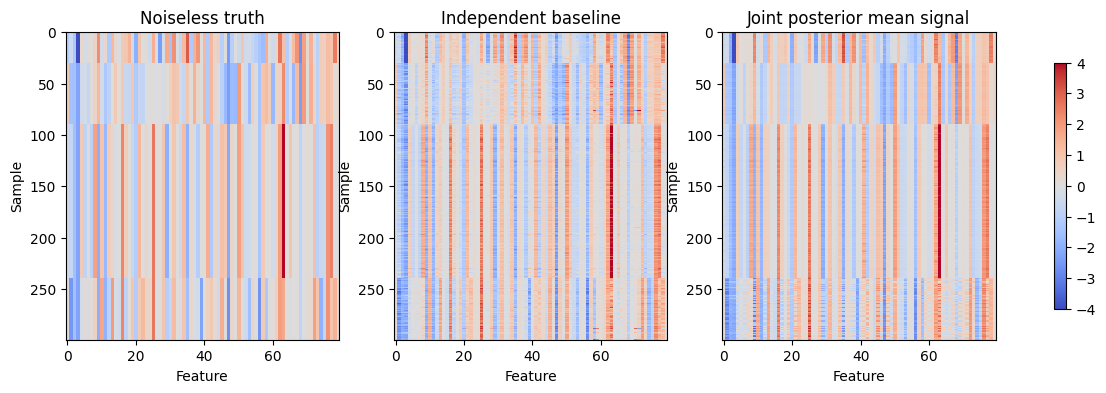

In [3]:
print("Baseline signal RMSE:", report["signal_rmse_baseline"])
print("Joint signal RMSE:   ", report["signal_rmse_joint"])
print("Baseline held-out RMSE:", report["heldout_rmse_baseline"])
print("Joint held-out RMSE:   ", report["heldout_rmse_joint"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, value, title in zip(axes, (sim["signal"], baseline.L @ baseline.F.T, result.reconstruction),
                          ("Noiseless truth", "Independent baseline", "Joint posterior mean signal")):
    image = ax.imshow(value.numpy(), aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-4, vmax=4)
    ax.set(title=title, xlabel="Feature", ylabel="Sample")
fig.colorbar(image, ax=axes.tolist(), shrink=0.8)
plt.show()


Loading acceptance: [0.8686666666666664, 0.9508333333333333, 0.99975, 0.9961666666666664, 0.9200833333333334, 1.0, 1.0, 1.0]


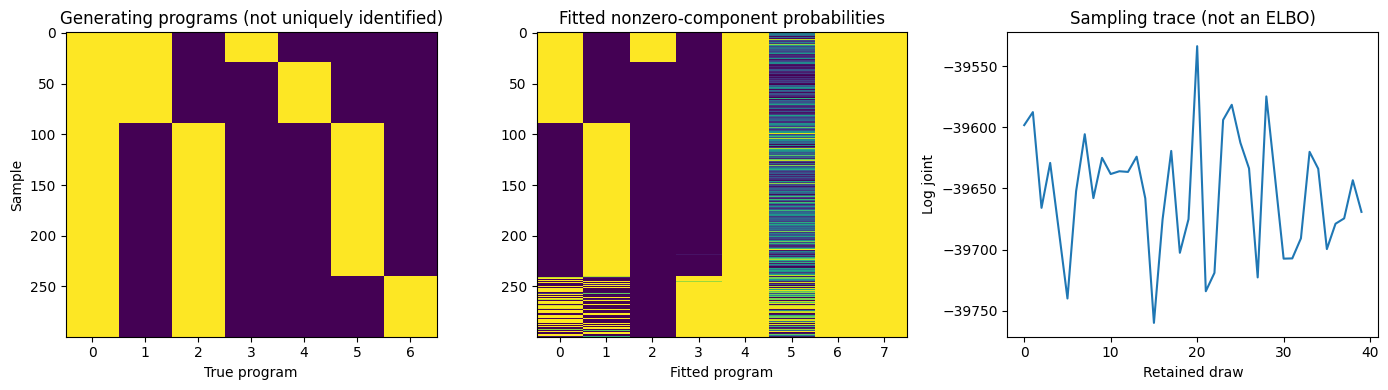

In [4]:
post = result.joint_posterior
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(sim["L"].numpy(), aspect="auto", interpolation="nearest", cmap="viridis")
axes[0].set(title="Generating programs (not uniquely identified)", xlabel="True program", ylabel="Sample")
axes[1].imshow(post.inclusion_probability_L.numpy(), aspect="auto", interpolation="nearest", vmin=0, vmax=1, cmap="viridis")
axes[1].set(title="Fitted nonzero-component probabilities", xlabel="Fitted program")
axes[2].plot(post.log_joint)
axes[2].set(title="Sampling trace (not an ELBO)", xlabel="Retained draw", ylabel="Log joint")
fig.tight_layout()
plt.show()
print("Loading acceptance:", post.acceptance_L.tolist())


## Use your own matrix

The same call works with your `Z` matrix. Supply its actual noise SD in `S` if known.
`fit(maxit)` uses `maxit` rounds of joint prior learning, then the sampling settings below.
`iter_once()` instead advances a single sweep with the fitted parameters fixed.

```python
model = cEBMF(
    data=Z, K=10, prior_L="cgb_sharp_2", prior_F="norm",
    self_row_cov=True, S=1.25, device="cpu",
    prior_L_kwargs={"omega": 0.01},
    joint_kwargs={"burnin": 100, "draws": 150, "thin": 2},
)
model.initialise_factors()
result = model.fit(8)
fitted_signal = result.reconstruction
```

For fitted starting values use `model.initialise_factors(L=L_start, F=F_start)` with
`K` matching their columns; these skip the independent initialization fit. For a column
hierarchy also set `self_col_cov=True` and choose a learned `prior_F`, such as `spiked_emdn`.
The HMM ignores self-covariates on its own axis.

Legacy `penalty`/`n_epochs`/`batch_size` do not define the normalized joint-prior objective
and produce a warning if supplied. Use `joint_kwargs` to control learning. Gaussian
observation noise, rank and non-neural priors remain fixed after initialization.
Short chains and good acceptance do not certify convergence or tree recovery.
